# Facebook Engagement Analysis – Data Cleaning & Preprocessing

Author: Nick Peril  
Project: TKH Phase I Portfolio

### Objective
To clean and preprocess the dataset in preparation for modeling.

### Project Goal:

To predict Facebook post engagement (Total Interactions) and identify which factors influence it.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Standardizing Column Names:

Since my datasets' column names have spaces and capitalizations, I cleaned them following the naming conventions for variables for easier coding.

In [2]:
df = pd.read_csv("/Users/saadult/facebook-metrics/data/01_raw/dataset_Facebook.csv", sep=';')
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [3]:
df.columns

Index(['page_total_likes', 'type', 'category', 'post_month', 'post_weekday',
       'post_hour', 'paid', 'lifetime_post_total_reach',
       'lifetime_post_total_impressions', 'lifetime_engaged_users',
       'lifetime_post_consumers', 'lifetime_post_consumptions',
       'lifetime_post_impressions_by_people_who_have_liked_your_page',
       'lifetime_post_reach_by_people_who_like_your_page',
       'lifetime_people_who_have_liked_your_page_and_engaged_with_your_post',
       'comment', 'like', 'share', 'total_interactions'],
      dtype='object')

### Removing Unnecessary Columns

In [4]:
df = df.drop(columns=['like', 'share', 'comment', 'lifetime_post_total_reach', 'lifetime_post_total_impressions', 'lifetime_engaged_users',
       'lifetime_post_consumers', 'lifetime_post_consumptions',
       'lifetime_post_impressions_by_people_who_have_liked_your_page',
       'lifetime_post_reach_by_people_who_like_your_page',
       'lifetime_people_who_have_liked_your_page_and_engaged_with_your_post'])

Since these features are post-performance metrics that occur after the post is published, I will need to drop them to avoid data leakage/multicollinearity. My target variable is total_interactions, which is also a post-performance metric, so if I'm going to use those variables I'm essentially predicting engagement using other engagement metrics.

### Handling Missing Values

There are missing values in few columns such as 'paid', 'like', and 'share'. Since the missing values only accounts to less than 1% of the total dataset, these rows were removed to avoid artificial values through imputation.

In [5]:
df.isnull().sum()

page_total_likes      0
type                  0
category              0
post_month            0
post_weekday          0
post_hour             0
paid                  1
total_interactions    0
dtype: int64

In [6]:
df = df.dropna()

### Log transform total_interactions feature

In [7]:
print("Skew before:")
print(f"  total_interactions:  {df['total_interactions'].skew():.2f}")

df['total_interactions_log'] = np.log1p(df['total_interactions'])

print("\nSkew after:")
print(f"  total_interactions_log:  {df['total_interactions_log'].skew():.2f}")

df = df.drop(columns=['total_interactions'])

Skew before:
  total_interactions:  9.70

Skew after:
  total_interactions_log:  -1.01


Below 0.5 — fine as-is

0.5 to 1 — moderate, worth considering a transform

Above 1 — high, transform recommended

### Binning Time Feature

In [8]:
'''
0-5: night
6-11: morning
12-17 afternoon
18-23 evening
'''

bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']

df['time_of_day'] = pd.cut(df['post_hour'], bins=bins, labels=labels, right=False)
df['time_of_day'].value_counts()

time_of_day
night        195
morning      193
afternoon    104
evening        7
Name: count, dtype: int64

### Handling categorical variables

In [9]:
df = pd.get_dummies(df, columns=['type', 'post_weekday', 'time_of_day'], drop_first=True, dtype=int)

df.head()

,page_total_likes,category,post_month,post_hour,paid,total_interactions_log,type_Photo,type_Status,type_Video,post_weekday_2,post_weekday_3,post_weekday_4,post_weekday_5,post_weekday_6,post_weekday_7,time_of_day_morning,time_of_day_afternoon,time_of_day_evening
0,139441,2,12,3,0.0,4.615121,1,0,0,0,0,1,0,0,0,0,0,0
1,139441,2,12,10,0.0,5.105945,0,1,0,0,1,0,0,0,0,1,0,0
2,139441,3,12,3,0.0,4.394449,1,0,0,0,1,0,0,0,0,0,0,0
3,139441,2,12,10,1.0,7.483244,1,0,0,1,0,0,0,0,0,1,0,0
4,139441,2,12,3,0.0,5.976351,1,0,0,1,0,0,0,0,0,0,0,0


I encoded categorical variable 'type' because its values are object, need to convert them into numeric using one-hot encoding. For categorical variable 'post_weekdays', although it is already numeric in value, I still need to one-hot encode it because linear regression might assume numeric relationship (ie. Tue (2) is greater than Mon (1)) when there is no mathematical meaning between them.

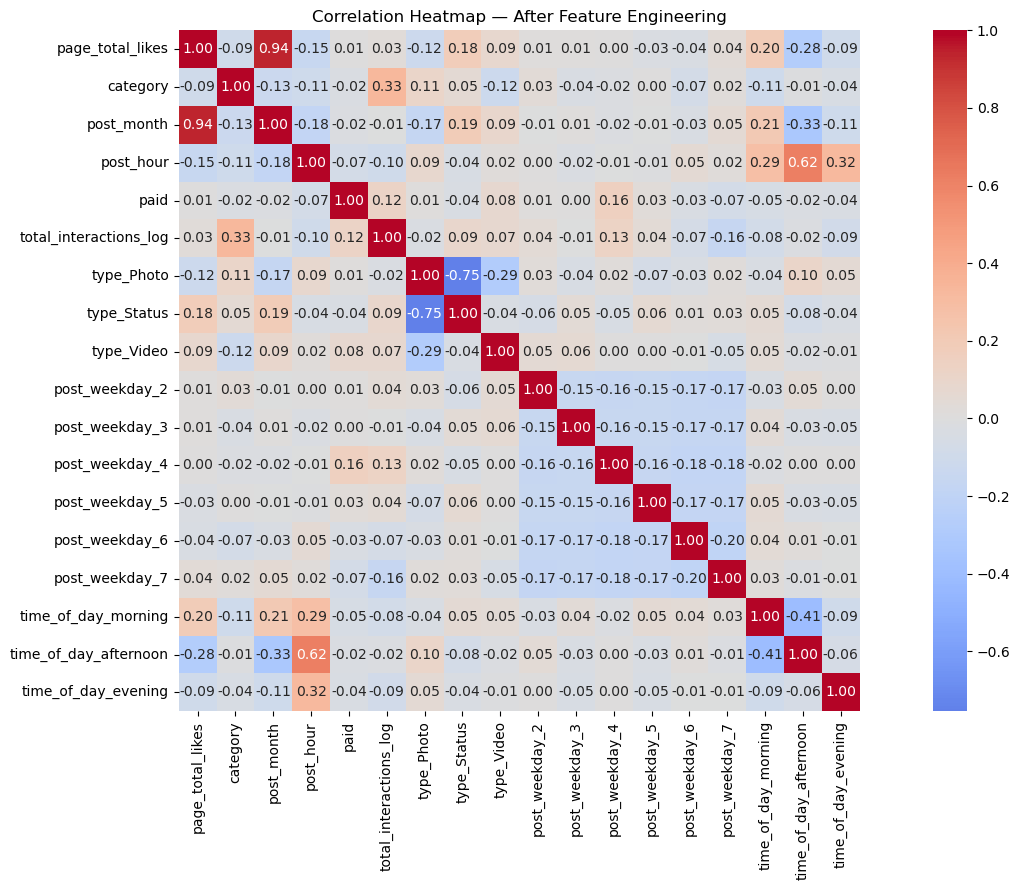


Correlation with target:
 total_interactions_log    1.000000
category                  0.329904
post_weekday_4            0.126806
paid                      0.116911
type_Status               0.091685
type_Video                0.073087
post_weekday_2            0.043694
post_weekday_5            0.041153
page_total_likes          0.027680
post_month               -0.005533
post_weekday_3           -0.005820
time_of_day_afternoon    -0.016505
type_Photo               -0.021639
post_weekday_6           -0.066711
time_of_day_morning      -0.079603
time_of_day_evening      -0.088043
post_hour                -0.101921
post_weekday_7           -0.158310
Name: total_interactions_log, dtype: float64


In [17]:
corr = df.corr()

plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — After Feature Engineering')
plt.tight_layout()
plt.savefig("../docs/images/corr_feature_engineer.png")
plt.show()

print("\nCorrelation with target:\n", corr['total_interactions_log'].sort_values(ascending=False))

### Key Findings:

1. 'category' has a moderate positive correlation with total_interactions. This means that posts in certain categories tend to receive higher interactions.
2. 'paid' has a weak positive correlation. Paid posts may slightly increase engagement but the effect is small.
3. 'post_hour' has a very weak negative relationship. Posting later in the day may slightly reduce engagement, but effect is minimal.
4. Post 'types' has very weak correlations. Post type alone may not strongly influence engagement.
5. Time of day has almost no relationship, it may not significantly affect engagement.  

### Final Check

In [15]:
print(df.shape)
print(df.isnull().sum())
df.dtypes

(499, 18)
page_total_likes          0
category                  0
post_month                0
post_hour                 0
paid                      0
total_interactions_log    0
type_Photo                0
type_Status               0
type_Video                0
post_weekday_2            0
post_weekday_3            0
post_weekday_4            0
post_weekday_5            0
post_weekday_6            0
post_weekday_7            0
time_of_day_morning       0
time_of_day_afternoon     0
time_of_day_evening       0
dtype: int64


page_total_likes            int64
category                    int64
post_month                  int64
post_hour                   int64
paid                      float64
total_interactions_log    float64
type_Photo                  int64
type_Status                 int64
type_Video                  int64
post_weekday_2              int64
post_weekday_3              int64
post_weekday_4              int64
post_weekday_5              int64
post_weekday_6              int64
post_weekday_7              int64
time_of_day_morning         int64
time_of_day_afternoon       int64
time_of_day_evening         int64
dtype: object

In [16]:
df.to_csv('../data/02_clean/facebook_clean.csv', index=False)